# Tuned threshold + class weights for business-cost optimization

In [ ]:
# importing libraries 

# Core
import pandas as pd
import numpy as np

# Preprocessing & pipelines
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
# Models
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    f1_score,
    accuracy_score,
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# Utilities
import warnings
warnings.filterwarnings('ignore')

## 1. Load data, rebuild features, fit winning model

In [18]:
df = pd.read_csv("../data/processed/cleaned.csv")
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,No,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,No,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,No,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,No,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,No,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [19]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
y_train = y_train.map({"No": 0, "Yes":1 })
y_test = y_test.map({"No": 0, "Yes":1 })

In [21]:
# adding feature
def add_features(X:pd.DataFrame):
    # turn `tenure` column into buckets
    bin_edges = [0, 12, 24, 48, 72]
    bin_labels = ['0-12', '13-24', '25-48', '49-72']
    X['tenure_bucket'] = pd.cut(X['tenure'], bins=bin_edges, labels=bin_labels, include_lowest=True)

    # count the number of services available per customer
    services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
    X["services_count"] = (X[services]=="Yes").sum(axis=1)

    # flag a new customer
    def check_new_customer(tenure):
        if tenure < 6:
            return 1
        else:
            return 0
    X["is_new_customer"] = X["tenure"].map(check_new_customer)

    # check for automatic payment
    def check_automatic_payment(payment_method):
        if "automatic" in payment_method:
            return 1
        else:
            return 0
    X["has_auto_payment"] = X["PaymentMethod"].map(check_automatic_payment)
    X["monthly_charge_per_tenure"] = (X["MonthlyCharges"]/(X["tenure"]+1))
    return X

X_train_features = add_features(X_train.copy())
X_test_features = add_features(X_test.copy())

In [22]:
num_cols = ["tenure", "MonthlyCharges","services_count", "monthly_charge_per_tenure"]
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PaperlessBilling"]
nominal_cols = ["InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod", "tenure_bucket"]

# binary map before implementing column transformer
for col in binary_cols:
    X_train_features[col] = X_train_features[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})
    X_test_features[col] = X_test_features[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_cols)
], remainder="passthrough")
# fitting the winning model on the train+features
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])


## 2. Recap — default threshold 0.5

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

pipe.fit(X_train_features, y_train)
y_prob = pipe.predict_proba(X_test_features)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

def evaluate_model(y_test, y_pred, y_prob, model_name="Model"):

    metrics = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC AUC":   roc_auc_score(y_test, y_prob),
    }

    print(f"\n{'='*40}")
    print(f"  {model_name} Results")
    print(f"{'='*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Evaluation", fontsize=14)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False,cmap="Blues")
    axes[0].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['ROC AUC']:.4f}")
    axes[1].plot([0,1], [0,1], '--', color='gray', alpha=0.5, label='Chance')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics


  Default LogReg @ threshold = 0.5 Results
  Accuracy    : 0.7977
  Precision   : 0.6540
  Recall      : 0.5053
  F1 Score    : 0.5701
  ROC AUC     : 0.8446


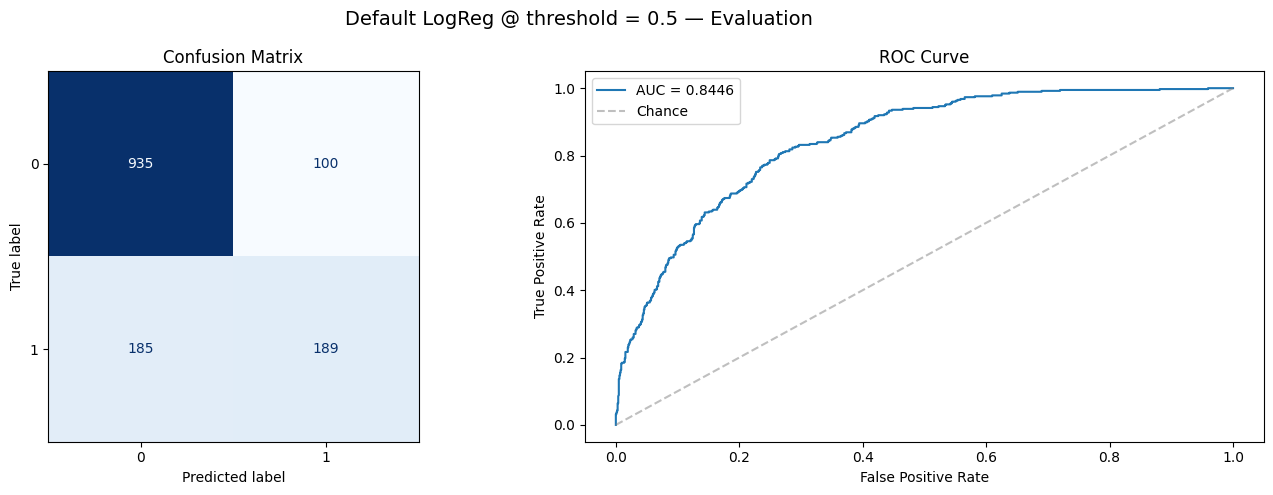

In [ ]:
Default_LogReg = evaluate_model(y_pred=y_pred, y_prob=y_prob, y_test=y_test,model_name="Default LogReg @ threshold = 0.5")

Notice that: **Recall** is around ~51%, and from a business point of view this will cost the company around £300 – £1000 per customer. in order to fix this issue we will make some concessions related to FP samples.

## 3. ROC vs PR curve

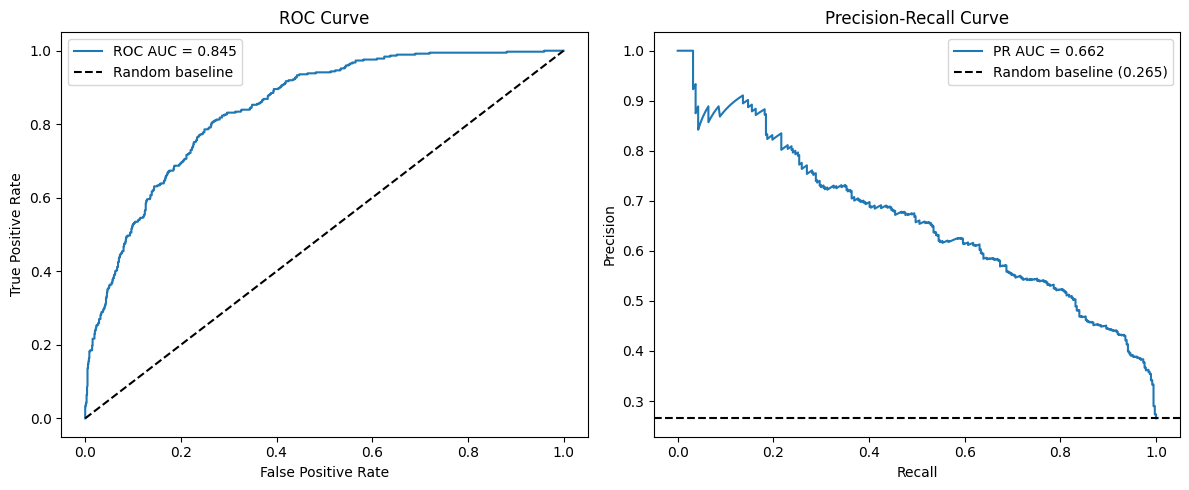

In [ ]:
# assuming y_test and y_prob already exist

from sklearn.metrics import average_precision_score


prevalence = y_test.mean()

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

ax2.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
ax2.axhline(y=prevalence, color='k', linestyle='--', label=f'Random baseline ({prevalence:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

because our data is imbalanced, so the PR curve is more informative than the ROC curve

- it tells us how the recall will looks like with different thresholds
- it shows the fact about the concessions we will do with precision


## 4. Threshold sweep

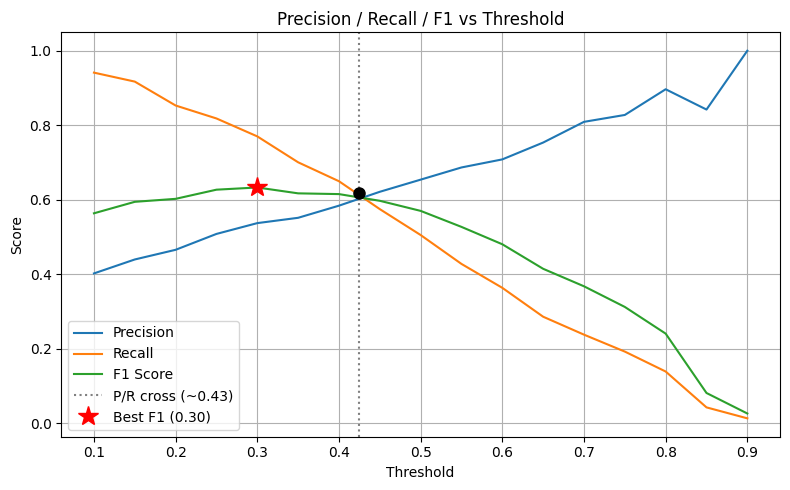

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(start=0.1, stop=0.91, step=0.05)
precisions = []
recalls = []
f1s = []

for threshold in thresholds:
    y_pred_labels = (y_prob >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_labels))
    recalls.append(recall_score(y_test, y_pred_labels))
    f1s.append(f1_score(y_test, y_pred_labels))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)

# find crossing point (where precision - recall flips sign)
diff = precisions - recalls
cross_idx = np.where(np.diff(np.sign(diff)))[0][0]
cross_threshold = (thresholds[cross_idx] + thresholds[cross_idx + 1]) / 2
cross_value = (precisions[cross_idx] + recalls[cross_idx]) / 2

# find best F1
best_f1_idx = np.argmax(f1s)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1 Score')

plt.axvline(x=cross_threshold, color='gray', linestyle=':', label=f'P/R cross (~{cross_threshold:.2f})')
plt.plot(cross_threshold, cross_value, 'ko', markersize=8)

plt.plot(thresholds[best_f1_idx], f1s[best_f1_idx], 'r*', markersize=15, label=f'Best F1 ({thresholds[best_f1_idx]:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Pick a threshold by target recall

In [ ]:
target_recall = 0.70
target_threshold_default = None
for t in sorted(thresholds, reverse=True):   # high threshold first
    y_tmp = (y_prob >= t).astype(int)
    if recall_score(y_test, y_tmp) >= target_recall:
        target_threshold_default = t
        break
print(f"Threshold for recall >= {target_recall}: {target_threshold_default:.2f}")

Threshold for recall >= 0.7: 0.35



  Default LogReg @ tuned threshold Results
  Accuracy    : 0.7693
  Precision   : 0.5516
  Recall      : 0.7005
  F1 Score    : 0.6172
  ROC AUC     : 0.8446


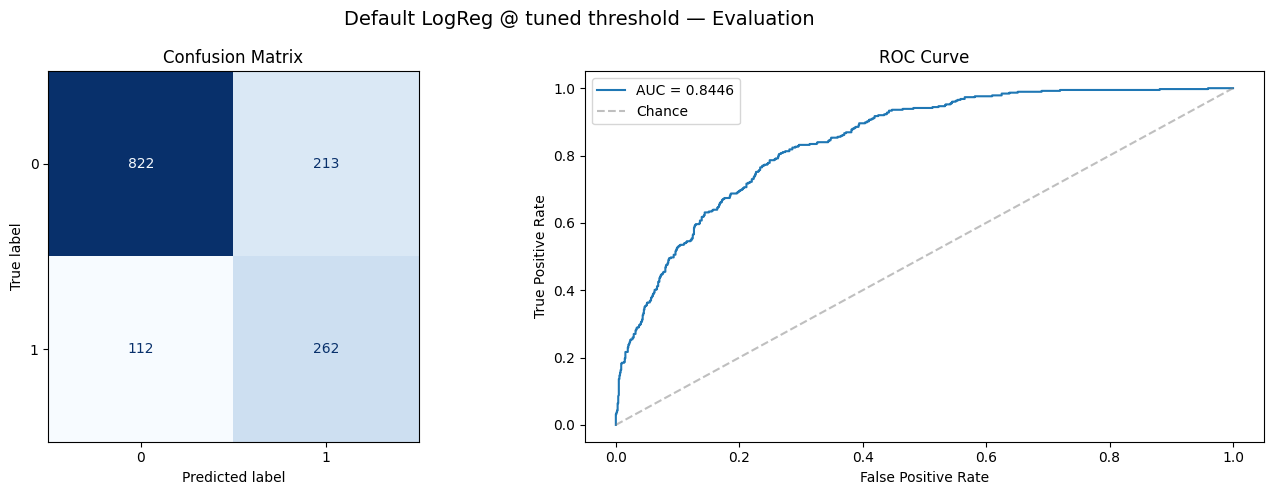

In [ ]:
y_pred_labels = (y_prob >= target_threshold_default).astype(int) # this will be used with different thresholds

Default_LogReg_tuned = evaluate_model(y_test= y_test,y_pred=y_pred_labels,y_prob=y_prob,model_name="Default LogReg @ tuned threshold")

for threshold that gives us a 70% recall we could do the following:
1. we caught 262 out of 374 churners
2. precision around 55% means 213 false alarm
3. Value: 262 × £650 saved = £170,300, minus 213 × £30 = £6,390 wasted on offers with the fake churners
4. Net business value ≈ £164,000

## 6. Alternative lever — class_weight='balanced'

In [32]:
pipe_balanced = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
pipe_balanced.fit(X_train_features, y_train)
y_prob_balanced = pipe_balanced.predict_proba(X_test_features)[:, 1]
y_pred_labels_balanced = (y_prob_balanced>=0.5).astype(int)


  Balanced LogReg @ threshold 0.5 Results
  Accuracy    : 0.7502
  Precision   : 0.5188
  Recall      : 0.8128
  F1 Score    : 0.6333
  ROC AUC     : 0.8448


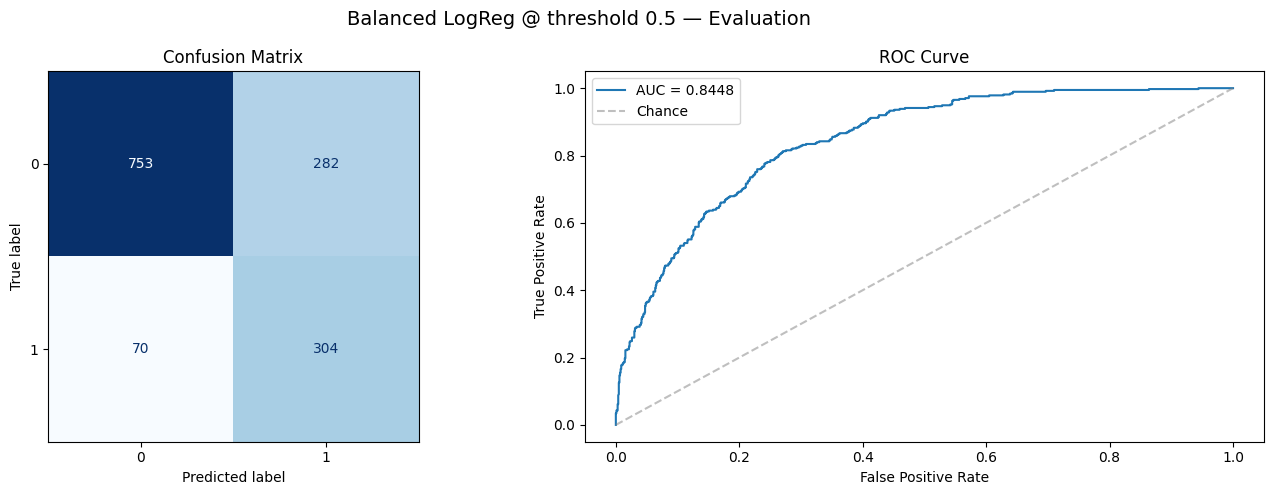

In [33]:
balanced_LogReg= evaluate_model(y_test=y_test, y_pred=y_pred_labels_balanced, y_prob=y_prob_balanced,model_name="Balanced LogReg @ threshold 0.5")

threshold sweep for the new model

In [ ]:
target_recall = 0.70
target_threshold_balanced = None
for t in sorted(thresholds, reverse=True):   # high threshold first
    y_tmp = (y_prob_balanced >= t).astype(int)
    if recall_score(y_test, y_tmp) >= target_recall:
        target_threshold_balanced = t
        break
print(f"Threshold for recall >= {target_recall}: {target_threshold_balanced:.2f}")

Threshold for recall >= 0.7: 0.55


In [ ]:
y_pred_labels_balanced_with_threshold = (y_prob_balanced>=target_threshold_balanced).astype(int)


  Balanced LogReg @ threshold 0.55 Results
  Accuracy    : 0.7658
  Precision   : 0.5420
  Recall      : 0.7594
  F1 Score    : 0.6325
  ROC AUC     : 0.8448


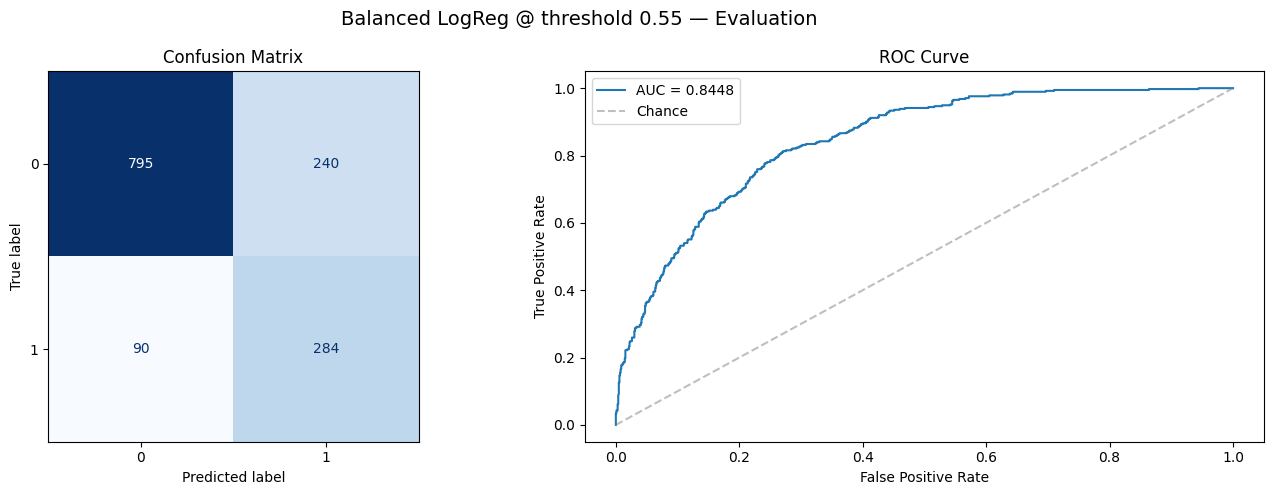

In [50]:
balanced_LogReg_with_threshold= evaluate_model(y_test=y_test, y_pred=y_pred_labels_balanced_with_threshold, 
                                                y_prob=y_prob_balanced,model_name="Balanced LogReg @ threshold 0.55")

making `class_weight = balanced` with `threshold ~0.55` that made recall goes from 70% up to ~81.3% and then back to ~76% after applying the threshold.

1. FN goes from 112 to 70 to 90 
2. FP increased from 213 to 282 to 240 

## 7. Calibration

In [43]:
def draw_calibration(model, X_test, y_test, model_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, ax=ax, name="LogReg")
    plt.title(f"Calibration Curve For {model_name}")
    plt.tight_layout()
    plt.show()

    # 27. Brier score
    y_proba = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_proba) # mse between probabilities and ground truth labels
    print(f"Brier Score: {brier:.4f}")

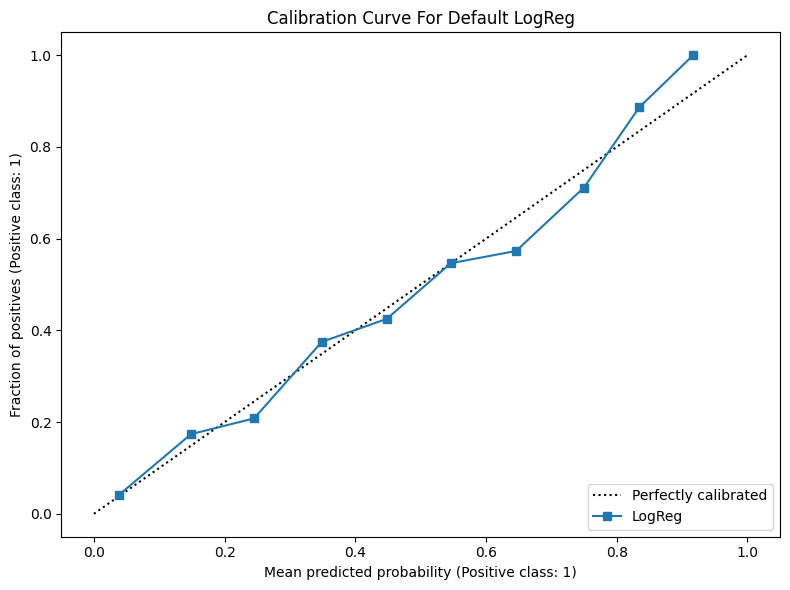

Brier Score: 0.1359


In [44]:
draw_calibration(pipe,X_test_features, y_test, model_name="Default LogReg")

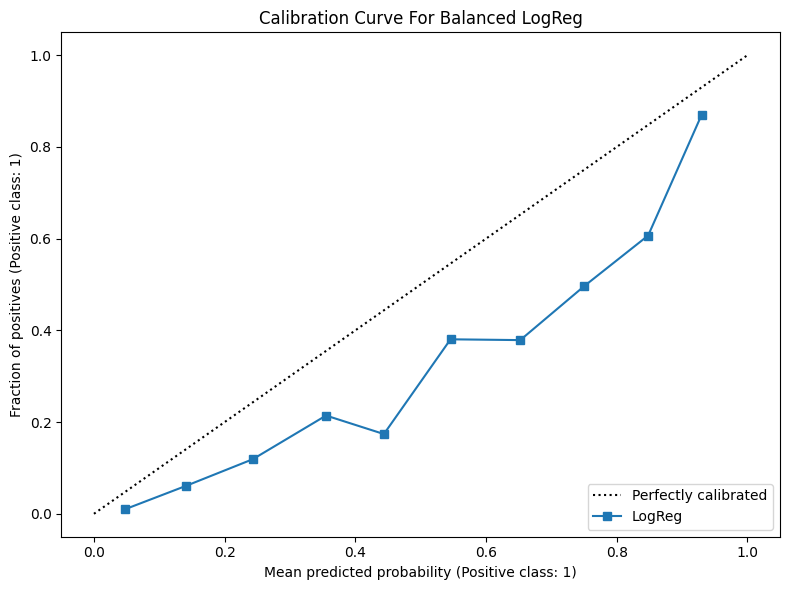

Brier Score: 0.1654


In [45]:
draw_calibration(pipe_balanced,X_test_features, y_test, model_name="Balanced LogReg")

# 8. Final decision

<div align="center">

| Model | Recall | Brier Score |
|:-------|:-----:|:------:|
| Default LogReg @ threshold 0.5  | 51% | **0.1359** |
| Default LogReg @ tuned threshold | 70% | **0.1359** |
| Balanced LogReg @ threshold 0.5    | 81% | **0.1654** |
| Balanced LogReg @ tuned threshold  | 76% | **0.1654** |

</div>

between these 4 models, there are 2 that out of this comparison **Balanced LogReg @ tuned threshold** and **Default LogReg @ threshold 0.5**, and this because in each of them case, there is a model the give better performance.

the comparison between **Default LogReg @ tuned threshold** and **Balanced LogReg @ threshold 0.5**
- the first one give me recall around 70% but it's more trusted because of Calibration Curve
- the second one give me recall around 81% but it's bad on the Calibration Curve, because of the balancing.

both are good from a business perspective if 
- you need a model that will only say "Yes" or "No", you will go with the **Balanced LogReg @ threshold 0.5**
- if you need a model that will give a trusted probability that you will use it, so **Default LogReg @ tuned threshold** will win.

because of in the deployment, Fastapi we will probability and also changing the threshold will be something that will be done without retraining again the winner of this will be  <span style="color:red"> <b> Default LogReg @ tuned threshold</b></span>